# Project 1 — LightGBM Regressor
## Delivery Time Prediction

Predicting delivery time (minutes) from distance, traffic level, weather score, and number of stops on the route.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
np.random.seed(42)
pd.set_option('display.max_columns', None)


## 1. Generate / Load Data

In [2]:
n = 900
distance = np.random.gamma(3, 3, n)
traffic_level = np.random.uniform(0, 10, n)
weather_score = np.random.uniform(0, 10, n)   # 10 = perfect weather, 0 = terrible
num_stops = np.random.poisson(2, n)

delivery_time = (10 + 3.5*distance + 2.2*traffic_level - 0.8*weather_score
                  + 4*num_stops + np.random.normal(0, 4, n)).clip(5, None)

df = pd.DataFrame({'distance': distance, 'traffic_level': traffic_level,
                    'weather_score': weather_score, 'num_stops': num_stops,
                    'delivery_time': delivery_time})
df.head()


,distance,traffic_level,weather_score,num_stops,delivery_time
0,10.688456,0.676684,5.138545,3,56.290321
1,7.341583,7.078351,5.088906,1,50.351252
2,6.906842,5.435382,3.692808,3,58.163986
3,6.906915,0.817253,9.329249,2,37.811071
4,18.498420,4.583006,8.275063,4,103.310335


## 2. Preprocessing

In [3]:
X = df.drop('delivery_time', axis=1)
y = df['delivery_time']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## 3. Train Model

In [4]:
from lightgbm import LGBMRegressor

model = LGBMRegressor(n_estimators=300, learning_rate=0.05, num_leaves=15,
                       min_child_samples=15, subsample=0.8, colsample_bytree=0.8,
                       random_state=42, verbose=-1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


## 4. Evaluate

In [5]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))


MAE: 3.863572301031146
RMSE: 4.76009125967171
R2 Score: 0.9433706478700773


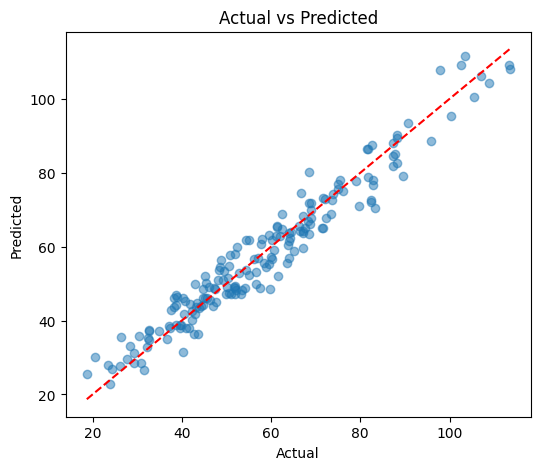

In [6]:
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred, alpha=0.5)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--')
plt.xlabel('Actual'); plt.ylabel('Predicted'); plt.title('Actual vs Predicted')
plt.show()


## Takeaways
- Check `model.feature_importances_` — distance and num_stops should be the top drivers.
- Notice `num_leaves=15` is set conservatively (data here is moderate-sized); try `num_leaves=100` to observe overfitting risk from leaf-wise growth.
- Next steps: compare training time against `XGBRegressor` on the same data — LightGBM should train noticeably faster.

---
# Project 2 — Your Turn
**Dataset:** fMRI dataset (`seaborn.load_dataset('fmri')`) — predict brain `signal` from `timepoint`, `event`, and `region`.

```python
import seaborn as sns
fmri = sns.load_dataset('fmri')
```
**Tasks:** encode categorical columns (`event`, `region`), train LightGBM Regressor, tune `num_leaves`, evaluate with MAE/RMSE/R².
